# DineSense Aspect Engine: Aspect Classification-Only Evaluation
## Multi-Label Benchmark on the 2,000-Review annotated Dataset

### 1. Executive Summary & Evaluation Objective
This Jupyter Notebook performs a **classification-only evaluation** of the DineSense **Hybrid Aspect Engine** (`match_aspect_hybrid`) against the calibrated human-annotated dataset comprising **2,000 restaurant reviews**.

#### Core Evaluation Scope
* **Isolated Classification Benchmark:** This evaluation isolates the model's **aspect classification capability** from upstream clause segmentation. It specifically measures: *"Given a coherent grammatical clause, how accurately does the hybrid engine identify aspect opinions across the 5 core business categories?"*
* **Multi-Label Problem Formulation:** Because a single clause may evaluate multiple restaurant aspects simultaneously (e.g., *"The food was delicious but the bill was expensive"* $\rightarrow$ `Food`, `Price / Value`), evaluation is treated strictly as **multi-label classification**.
* **Five Aspect Categories:**
  1. `Food`
  2. `Service`
  3. `Price / Value`
  4. `Ambience`
  5. `General Experience`
* **Handling of 'No Aspect Opinion':** Non-evaluative clauses (e.g. narrative facts, procedural details) are represented as the **absence of all 5 aspect labels** (`No Aspect Opinion`). This is tracked separately as a negative-class detection metric and is **not** conflated as a sixth aspect category in Macro/Micro calculations.
* **Deterministic Clause Alignment:** Rather than assuming sequential row order, every record is strictly joined using unique `review_id` and `clause_id` keys, with cross-verification on `clause_text`.


---
## 2. Theoretical & Empirical Context: Clause Segmentation vs. Aspect Classification

In an end-to-end production deployment, DineSense processes raw reviews through a two-stage pipeline:
1. **Discourse Clause Segmentation (`split_into_clauses`):** Uses SpaCy syntactic dependency parsing combined with Rhetorical Structure Theory (RST) contrastive discourse markers (`but`, `however`, `although`, `yet`, semicolons) to split sentences into evaluative units.
2. **Hybrid Aspect Classification (`match_aspect_hybrid`):** Curated lexical-priority regex matching (Tier 1) with MiniLM semantic centroid fallback (Tier 2).

### Overall Clause Comparison
Empirical analysis of the 2,000 raw reviews processed through `split_into_clauses` versus the human-annotated reference clauses:

| Source | Total Clauses | Average Clauses / Review |
|---|---:|---:|
| Annotated Dataset (`annotations_2000_final.csv`) | 11,631 | 5.82 |
| Aspect Engine Segmentation (`split_into_clauses`) | 10,993 | 5.50 |
| Difference | -638 (94.51% match ratio) | -0.32 |

### Detailed Difference Distribution Across Reviews

| Per-Review Clause Difference (Δ = Engine − Annotated) | Number of Reviews | Percentage |
|---|---:|---:|
| Δ = 0 (Identical Count) | 1,473 | 73.7% |
| Δ = −1 | 274 | 13.7% |
| Δ = +1 | 83 | 4.2% |
| Δ = −2 | 83 | 4.2% |
| Δ = +2 | 12 | 0.6% |
| Δ ≤ −3 (Complex multi-sentence paragraphs) | 73 | 3.6% |
| Δ ≥ +3 | 2 | 0.1% |

### Methodological Interpretation
* **Clause-Count Agreement, Not Boundary Identity:** The **94.51%** figure represents the total clause count ratio (10,993 / 11,631). It is **not** an aspect classification accuracy or token-boundary accuracy metric.
* **Rationale for Decoupled Evaluation:** In **1,473 of 2,000 reviews (73.7%)**, the per-review clause count is 100% identical. However, in the remaining 26.3% of reviews, slight tokenization variances (such as splitting on comma lists or coordinating conjunctions) create alignment shifts.
* Following standard ABSA research protocols (e.g. SemEval-2014 Task 4, SemEval-2016 Task 5), evaluating aspect categorization on **gold-standard human clause boundaries** isolates classifier performance from upstream segmentation artifacts.


---
## 3. Environment Setup & Configuration

All paths, category taxonomies, and schema column definitions are centralized in this configuration cell.


In [9]:
import os
import sys
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict, Counter

# Configure plot aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 10
warnings.filterwarnings('ignore')

# Determine workspace root
NOTEBOOK_DIR = os.path.abspath(os.getcwd())
PROJECT_ROOT = NOTEBOOK_DIR if os.path.exists(os.path.join(NOTEBOOK_DIR, 'src')) else os.path.dirname(NOTEBOOK_DIR)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print(f"Project Root: {PROJECT_ROOT}")

# =========================================================================
# CONFIGURATION SETTINGS
# =========================================================================
# File Paths with robust fallback resolution
ANNOTATION_CANDIDATES = [
    os.path.join(NOTEBOOK_DIR, '..', '01_datasets_and_preprocessing', 'modified_annotations_2000_human_annotated.csv'),
    os.path.join(NOTEBOOK_DIR, 'modified_annotations_2000_human_annotated.csv'),
    os.path.join(PROJECT_ROOT, 'final_aspect_evaluation', 'modified_annotations_2000_corrected_mixed.csv'),
    os.path.join(PROJECT_ROOT, 'final_aspect_evaluation', 'modified_annotations_2000.csv'),
    os.path.join(PROJECT_ROOT, 'hybrid_aligned_annotations.csv'),
    os.path.join(PROJECT_ROOT, 'annotation_dataset', 'hybrid_aligned_annotations.csv')
]

PREDICTION_CANDIDATES = [
    os.path.join(NOTEBOOK_DIR, '..', '03_predicted_aspects_2000', 'predicted_aspects_2000.csv'),
    os.path.join(NOTEBOOK_DIR, 'predicted_aspects_2000.csv'),
    os.path.join(PROJECT_ROOT, 'final_aspect_evaluation', 'predicted_aspects_2000.csv'),
    os.path.join(PROJECT_ROOT, 'aspect_evaluation', 'aspect_predictions_2000_calibrated.csv'),
    os.path.join(PROJECT_ROOT, 'aspect_evaluation', 'aspect_predictions_2000.csv')
]

ANNOTATION_PATH = next((p for p in ANNOTATION_CANDIDATES if os.path.exists(p)), None)
PREDICTION_PATH = next((p for p in PREDICTION_CANDIDATES if os.path.exists(p)), None)

# Taxonomy Definition
ASPECT_CATEGORIES = ['Food', 'Service', 'Price / Value', 'Ambience', 'General Experience']
ZERO_DIVISION_POLICY = 0.0

print(f"Annotation Dataset: {ANNOTATION_PATH}")
print(f"Predictions File:   {PREDICTION_PATH}")
print(f"Aspect Taxonomy:    {ASPECT_CATEGORIES}")

assert ANNOTATION_PATH is not None and os.path.exists(ANNOTATION_PATH), "Annotation dataset not found!"
assert PREDICTION_PATH is not None and os.path.exists(PREDICTION_PATH), "Predictions file not found!"

Project Root: d:\Aspect-Based-Sentimental-Analysis-on-Food-Reviews
Annotation Dataset: d:\Aspect-Based-Sentimental-Analysis-on-Food-Reviews\final_aspect_evaluation\modified_annotations_2000.csv
Predictions File:   d:\Aspect-Based-Sentimental-Analysis-on-Food-Reviews\final_aspect_evaluation\predicted_aspects_2000.csv
Aspect Taxonomy:    ['Food', 'Service', 'Price / Value', 'Ambience', 'General Experience']


---
## 4. Data Loading & Schema Inspection

In this step, we:
1. Load the modified human-annotated dataset (`modified_annotations_2000.csv`) and the hybrid prediction table (`predicted_aspects_2000.csv`).
2. Inspect schema dimensions, columns, null value distribution, and unique identifiers.
3. Aggregate assertion-level annotations into multi-label reference sets per unique clause.


In [10]:
# 1. Load Datasets
df_ann = pd.read_csv(ANNOTATION_PATH)
df_pred = pd.read_csv(PREDICTION_PATH)

print("="*60)
print(f"Annotation Table Shape:  {df_ann.shape[0]:,} rows, {df_ann.shape[1]} columns")
print(f"Prediction Table Shape:  {df_pred.shape[0]:,} rows, {df_pred.shape[1]} columns")
print("="*60)

# Display sample of annotation records
print("\n--- Annotation File Preview (First 3 Rows) ---")
display(df_ann[['assertion_id', 'clause_id', 'review_id', 'clause_text', 'aspect', 'sentiment', 'annotation_status']].head(3))

# Display sample of prediction records
print("\n--- Prediction File Preview (First 3 Rows) ---")
display(df_pred[['clause_id', 'review_id', 'clause_text', 'reference_aspect_labels', 'predicted_aspect_labels']].head(3))

# Identifier and Cardinality Checks
unique_reviews_ann = df_ann['review_id'].nunique()
unique_clauses_ann = df_ann['clause_id'].nunique()
unique_reviews_pred = df_pred['review_id'].nunique()
unique_clauses_pred = df_pred['clause_id'].nunique()

print("\n--- Identifier Cardinality ---")
print(f"Unique Reviews (Annotations): {unique_reviews_ann:,} | Unique Reviews (Predictions): {unique_reviews_pred:,}")
print(f"Unique Clauses (Annotations): {unique_clauses_ann:,} | Unique Clauses (Predictions): {unique_clauses_pred:,}")

# Check missing values
print("\n--- Null Values in Key Annotation Columns ---")
print(df_ann[['assertion_id', 'clause_id', 'review_id', 'clause_text', 'aspect', 'sentiment', 'annotation_status']].isna().sum())


Annotation Table Shape:  12,245 rows, 24 columns
Prediction Table Shape:  11,631 rows, 16 columns

--- Annotation File Preview (First 3 Rows) ---


,assertion_id,clause_id,review_id,clause_text,aspect,sentiment,annotation_status
0,REV_00073_C01_A01,REV_00073_C01,REV_00073,Had dinner at this place and the attendant was...,NaN,NaN,No Aspect Opinion
1,REV_00073_C02_A01,REV_00073_C02,REV_00073,The staff is very friendly and the ambiance is...,Service,Positive,Annotated
2,REV_00073_C03_A01,REV_00073_C03,REV_00073,Good variety of food and beverages,Food,Positive,Annotated



--- Prediction File Preview (First 3 Rows) ---


,clause_id,review_id,clause_text,reference_aspect_labels,predicted_aspect_labels
0,REV_00073_C01,REV_00073,Had dinner at this place and the attendant was...,[],"[""Service""]"
1,REV_00073_C02,REV_00073,The staff is very friendly and the ambiance is...,"[""Service""]","[""Ambience"", ""Service""]"
2,REV_00073_C03,REV_00073,Good variety of food and beverages,"[""Food""]","[""Food""]"



--- Identifier Cardinality ---
Unique Reviews (Annotations): 2,000 | Unique Reviews (Predictions): 2,000
Unique Clauses (Annotations): 11,631 | Unique Clauses (Predictions): 11,631

--- Null Values in Key Annotation Columns ---
assertion_id            0
clause_id               0
review_id               0
clause_text             0
aspect               4872
sentiment            6871
annotation_status       0
dtype: int64


---
## 5. Record Alignment & Integrity Audit

### Strict Non-Positional Key Matching
To guarantee benchmark validity, we **never assume rows match based on sequential order**. 
Records are aligned using composite keys `(review_id, clause_id)`. We verify:
* Reference clause count vs. predicted clause count.
* Exact clause text equality.
* Absence of unmatched or ambiguous/duplicate records.


In [11]:
# Aggregate assertion-level annotations into unique clause reference sets
reference_clause_dict = {}
for idx, row in df_ann.iterrows():
    cid = str(row['clause_id'])
    rid = str(row['review_id'])
    text = str(row['clause_text'])
    asp = row['aspect']
    
    if cid not in reference_clause_dict:
        reference_clause_dict[cid] = {
            'review_id': rid,
            'clause_text': text,
            'aspects': set()
        }
    if pd.notna(asp) and str(asp).strip() in ASPECT_CATEGORIES:
        reference_clause_dict[cid]['aspects'].add(str(asp).strip())

# Extract predictions indexed by clause_id
prediction_clause_dict = {}
for idx, row in df_pred.iterrows():
    cid = str(row['clause_id'])
    rid = str(row['review_id'])
    text = str(row['clause_text'])
    preds_raw = row['predicted_aspect_labels']
    preds_list = json.loads(preds_raw) if isinstance(preds_raw, str) else []
    
    prediction_clause_dict[cid] = {
        'review_id': rid,
        'clause_text': text,
        'predicted_aspects': set(preds_list)
    }

# Alignment Audit
ref_cids = set(reference_clause_dict.keys())
pred_cids = set(prediction_clause_dict.keys())

matched_cids = sorted(list(ref_cids.intersection(pred_cids)))
unmatched_ref = ref_cids - pred_cids
unmatched_pred = pred_cids - ref_cids

# Cross-verify clause text identity
text_mismatches = []
for cid in matched_cids:
    ref_txt = reference_clause_dict[cid]['clause_text'].strip()
    pred_txt = prediction_clause_dict[cid]['clause_text'].strip()
    if ref_txt != pred_txt:
        text_mismatches.append((cid, ref_txt, pred_txt))

alignment_summary = pd.DataFrame([
    {'Metric': 'Total Reference Clauses (Annotations)', 'Count': len(ref_cids), 'Proportion': '100.0%'},
    {'Metric': 'Total Predicted Clauses', 'Count': len(pred_cids), 'Proportion': '100.0%'},
    {'Metric': 'Matched Clauses (Joint Intersection)', 'Count': len(matched_cids), 'Proportion': f'{len(matched_cids)/len(ref_cids)*100:.2f}%'},
    {'Metric': 'Unmatched Reference Clauses', 'Count': len(unmatched_ref), 'Proportion': f'{len(unmatched_ref)/len(ref_cids)*100:.2f}%'},
    {'Metric': 'Unmatched Predicted Clauses', 'Count': len(unmatched_pred), 'Proportion': f'{len(unmatched_pred)/len(pred_cids)*100:.2f}%'},
    {'Metric': 'Clause Text Discrepancies', 'Count': len(text_mismatches), 'Proportion': f'{len(text_mismatches)/len(matched_cids)*100:.2f}%'}
])

print("="*70)
print("CLAUSE ALIGNMENT & INTEGRITY AUDIT")
print("="*70)
display(alignment_summary)

# Enforce strict benchmark invariant
assert len(unmatched_ref) == 0, f"Error: {len(unmatched_ref)} reference clauses were unmatched!"
assert len(unmatched_pred) == 0, f"Error: {len(unmatched_pred)} prediction clauses were unmatched!"
assert len(text_mismatches) == 0, f"Error: Found {len(text_mismatches)} clause text discrepancies!"
print(">>> INTEGRITY AUDIT PASSED: 100% 1-to-1 deterministic alignment confirmed across all 11,631 clauses.")


CLAUSE ALIGNMENT & INTEGRITY AUDIT


,Metric,Count,Proportion
0,Total Reference Clauses (Annotations),11631,100.0%
1,Total Predicted Clauses,11631,100.0%
2,Matched Clauses (Joint Intersection),11631,100.00%
3,Unmatched Reference Clauses,0,0.00%
4,Unmatched Predicted Clauses,0,0.00%
5,Clause Text Discrepancies,0,0.00%


>>> INTEGRITY AUDIT PASSED: 100% 1-to-1 deterministic alignment confirmed across all 11,631 clauses.


---
## 6. Multi-Label Aspect Classification Evaluation

### Evaluation Protocol
Because each clause can possess zero, one, or multiple aspect assignments, metrics are computed via **Binary One-vs-Rest (OvR)**:
* **True Positive (TP):** Aspect $c$ is present in both Reference and Predicted sets.
* **False Positive (FP):** Aspect $c$ is predicted by the engine but absent in Reference.
* **False Negative (FN):** Aspect $c$ is present in Reference but missed by the engine.
* **True Negative (TN):** Aspect $c$ is absent in both Reference and Predicted sets.

$$\text{Precision} = \frac{TP}{TP + FP}, \quad \text{Recall} = \frac{TP}{TP + FN}, \quad F_1 = \frac{2 \cdot \text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$

### Global Aggregations
* **Macro Average:** Unweighted mean of per-category metrics (treats all 5 aspects equally regardless of support).
* **Micro Average:** Globally summed $TP, FP, FN$ across the 5 categories (dominated by high-frequency aspects like `Food`).
* **Exact-Match Accuracy (Subset Accuracy):** Proportion of clauses where $\text{Predicted Aspects} == \text{Reference Aspects}$.
* **At-Least-One Match Recall:** Proportion of evaluative clauses where the model identified at least one correct aspect.
* **No Aspect Opinion Audit:** Explicitly tracks accuracy in identifying non-evaluative clauses without conflating it into the 5-aspect macro average.


In [12]:
# Extract parallel ground truth and prediction sets
ground_truth_sets = [reference_clause_dict[cid]['aspects'] for cid in matched_cids]
predicted_sets = [prediction_clause_dict[cid]['predicted_aspects'] for cid in matched_cids]

# 1. Compute Category-Level Contingency Tables & Metrics
cat_metrics = []
total_tp = total_fp = total_fn = 0
total_support = 0

for cat in ASPECT_CATEGORIES:
    tp = fp = fn = tn = 0
    for ref, pred in zip(ground_truth_sets, predicted_sets):
        in_ref = cat in ref
        in_pred = cat in pred
        if in_ref and in_pred:
            tp += 1
        elif not in_ref and in_pred:
            fp += 1
        elif in_ref and not in_pred:
            fn += 1
        else:
            tn += 1
            
    p = tp / (tp + fp) if (tp + fp) > 0 else ZERO_DIVISION_POLICY
    r = tp / (tp + fn) if (tp + fn) > 0 else ZERO_DIVISION_POLICY
    f1 = (2 * p * r) / (p + r) if (p + r) > 0 else ZERO_DIVISION_POLICY
    supp = tp + fn
    
    total_tp += tp
    total_fp += fp
    total_fn += fn
    total_support += supp
    
    cat_metrics.append({
        'Category': cat,
        'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
        'Precision': p,
        'Recall': r,
        'F1-Score': f1,
        'Support': supp
    })

# 2. No Aspect Opinion (Absence of All 5 Aspects)
tp_no = fp_no = fn_no = tn_no = 0
for ref, pred in zip(ground_truth_sets, predicted_sets):
    is_ref_no = len(ref) == 0
    is_pred_no = len(pred) == 0
    if is_ref_no and is_pred_no:
        tp_no += 1
    elif not is_ref_no and is_pred_no:
        fp_no += 1
    elif is_ref_no and not is_pred_no:
        fn_no += 1
    else:
        tp_no += 1

prec_no = tp_no / (tp_no + fp_no) if (tp_no + fp_no) > 0 else ZERO_DIVISION_POLICY
rec_no = tp_no / (tp_no + fn_no) if (tp_no + fn_no) > 0 else ZERO_DIVISION_POLICY
f1_no = (2 * prec_no * rec_no) / (prec_no + rec_no) if (prec_no + rec_no) > 0 else ZERO_DIVISION_POLICY

# 3. Macro and Micro Calculations across 5 Core Aspects
macro_p = np.mean([m['Precision'] for m in cat_metrics])
macro_r = np.mean([m['Recall'] for m in cat_metrics])
macro_f1 = np.mean([m['F1-Score'] for m in cat_metrics])

micro_p = total_tp / (total_tp + total_fp)
micro_r = total_tp / (total_tp + total_fn)
micro_f1 = (2 * micro_p * micro_r) / (micro_p + micro_r)

weighted_p = sum(m['Precision'] * m['Support'] for m in cat_metrics) / total_support
weighted_r = sum(m['Recall'] * m['Support'] for m in cat_metrics) / total_support
weighted_f1 = sum(m['F1-Score'] * m['Support'] for m in cat_metrics) / total_support

# Format Performance Table
report_rows = []
for m in cat_metrics:
    report_rows.append({
        'Category': m['Category'],
        'TP': f"{m['TP']:,}", 'FP': f"{m['FP']:,}", 'FN': f"{m['FN']:,}", 'TN': f"{m['TN']:,}",
        'Precision': f"{m['Precision']*100:.2f}%",
        'Recall': f"{m['Recall']*100:.2f}%",
        'F1-Score': f"{m['F1-Score']*100:.2f}%",
        'Support': f"{m['Support']:,}"
    })

# Add Negative Class
report_rows.append({
    'Category': 'No Aspect Opinion',
    'TP': f"{tp_no:,}", 'FP': f"{fp_no:,}", 'FN': f"{fn_no:,}", 'TN': f"{tn_no:,}",
    'Precision': f"{prec_no*100:.2f}%",
    'Recall': f"{rec_no*100:.2f}%",
    'F1-Score': f"{f1_no*100:.2f}%",
    'Support': f"{tp_no + fn_no:,}"
})

# Add Global Summaries
report_rows.append({
    'Category': 'Macro Average (5 Aspects)',
    'TP': f"{total_tp:,}", 'FP': f"{total_fp:,}", 'FN': f"{total_fn:,}", 'TN': '—',
    'Precision': f"{macro_p*100:.2f}%",
    'Recall': f"{macro_r*100:.2f}%",
    'F1-Score': f"{macro_f1*100:.2f}%",
    'Support': f"{total_support:,}"
})
report_rows.append({
    'Category': 'Micro Average (5 Aspects)',
    'TP': f"{total_tp:,}", 'FP': f"{total_fp:,}", 'FN': f"{total_fn:,}", 'TN': '—',
    'Precision': f"{micro_p*100:.2f}%",
    'Recall': f"{micro_r*100:.2f}%",
    'F1-Score': f"{micro_f1*100:.2f}%",
    'Support': f"{total_support:,}"
})

df_report = pd.DataFrame(report_rows)

print("="*85)
print("DINESENSE ASPECT CLASSIFICATION PERFORMANCE REPORT")
print("="*85)
display(df_report)


DINESENSE ASPECT CLASSIFICATION PERFORMANCE REPORT


,Category,TP,FP,FN,TN,Precision,Recall,F1-Score,Support
0,Food,"3,276","1,545",163,"6,647",67.95%,95.26%,79.32%,"3,439"
1,Service,"1,220",718,18,"9,675",62.95%,98.55%,76.83%,"1,238"
2,Price / Value,470,183,1,"10,977",71.98%,99.79%,83.63%,471
3,Ambience,879,424,24,"10,304",67.46%,97.34%,79.69%,903
4,General Experience,"1,017",333,305,"9,976",75.33%,76.93%,76.12%,"1,322"
5,No Aspect Opinion,"9,016",277,"2,338",0,97.02%,79.41%,87.33%,"11,354"
6,Macro Average (5 Aspects),"6,862","3,203",511,—,69.13%,93.57%,79.12%,"7,373"
7,Micro Average (5 Aspects),"6,862","3,203",511,—,68.18%,93.07%,78.70%,"7,373"


---
## 7. Global Agreement & Accuracy Metrics

Here we evaluate clause-level exact match accuracy, intersection-over-union (Jaccard similarity), and Hamming loss.


In [13]:
exact_matches = sum(1 for ref, pred in zip(ground_truth_sets, predicted_sets) if ref == pred)
exact_match_acc = exact_matches / len(matched_cids)

# Evaluative subset accuracy (clauses with >= 1 reference aspect)
eval_mask = [len(ref) > 0 for ref in ground_truth_sets]
eval_exact = sum(1 for i in range(len(matched_cids)) if eval_mask[i] and ground_truth_sets[i] == predicted_sets[i])
eval_overlap = sum(1 for i in range(len(matched_cids)) if eval_mask[i] and bool(ground_truth_sets[i] & predicted_sets[i]))
eval_total = sum(eval_mask)

# Jaccard similarities
jaccards = []
for ref, pred in zip(ground_truth_sets, predicted_sets):
    if not ref and not pred:
        jaccards.append(1.0)
    elif not ref or not pred:
        jaccards.append(0.0)
    else:
        jaccards.append(len(ref & pred) / len(ref | pred))
avg_jaccard = np.mean(jaccards)

# Multi-label Hamming Loss across 5 aspects
total_label_mismatches = 0
for ref, pred in zip(ground_truth_sets, predicted_sets):
    for cat in ASPECT_CATEGORIES:
        if (cat in ref) != (cat in pred):
            total_label_mismatches += 1
hamming_loss = total_label_mismatches / (len(matched_cids) * len(ASPECT_CATEGORIES))

summary_metrics_df = pd.DataFrame([
    {'Metric': 'Total Clauses Evaluated', 'Value': f"{len(matched_cids):,}", 'Description': 'Total unique clauses matched across 2,000 reviews'},
    {'Metric': 'Overall Exact Match Accuracy', 'Value': f"{exact_match_acc*100:.2f}%", 'Description': f'All aspect labels match identically ({exact_matches:,}/{len(matched_cids):,})'},
    {'Metric': 'Evaluative Exact Match Ratio', 'Value': f"{eval_exact/eval_total*100:.2f}%", 'Description': f'Exact match on clauses with >= 1 aspect ({eval_exact:,}/{eval_total:,})'},
    {'Metric': 'Evaluative At-Least-One Overlap', 'Value': f"{eval_overlap/eval_total*100:.2f}%", 'Description': f'Identified at least one correct aspect ({eval_overlap:,}/{eval_total:,})'},
    {'Metric': 'Macro F1-Score (5 Aspects)', 'Value': f"{macro_f1*100:.2f}%", 'Description': 'Unweighted mean F1 across core business aspects'},
    {'Metric': 'Micro F1-Score (5 Aspects)', 'Value': f"{micro_f1*100:.2f}%", 'Description': 'Globally pooled F1 across all aspect instances'},
    {'Metric': 'Average Jaccard Similarity', 'Value': f"{avg_jaccard*100:.2f}%", 'Description': 'Mean intersection-over-union across clause aspect sets'},
    {'Metric': 'Multi-Label Hamming Loss', 'Value': f"{hamming_loss*100:.2f}%", 'Description': 'Average fraction of incorrect binary aspect decisions'}
])

print("="*75)
print("OVERALL AGREEMENT & ACCURACY SUMMARY")
print("="*75)
display(summary_metrics_df)


OVERALL AGREEMENT & ACCURACY SUMMARY


,Metric,Value,Description
0,Total Clauses Evaluated,"11,631","Total unique clauses matched across 2,000 reviews"
1,Overall Exact Match Accuracy,72.67%,"All aspect labels match identically (8,452/11,..."
2,Evaluative Exact Match Ratio,87.56%,"Exact match on clauses with >= 1 aspect (5,918..."
3,Evaluative At-Least-One Overlap,92.44%,"Identified at least one correct aspect (6,248/..."
4,Macro F1-Score (5 Aspects),79.12%,Unweighted mean F1 across core business aspects
5,Micro F1-Score (5 Aspects),78.70%,Globally pooled F1 across all aspect instances
6,Average Jaccard Similarity,74.01%,Mean intersection-over-union across clause asp...
7,Multi-Label Hamming Loss,6.39%,Average fraction of incorrect binary aspect de...


---
## 8. Performance Visualizations

We generate four visual artifacts:
1. **Per-Aspect Precision, Recall, and F1-Score Bar Chart**
2. **Binary Confusion / Contingency Heatmaps (TP, FP, FN, TN)**
3. **Reference vs. Prediction Aspect Distribution (Support Comparison)**
4. **Summary Dashboard**


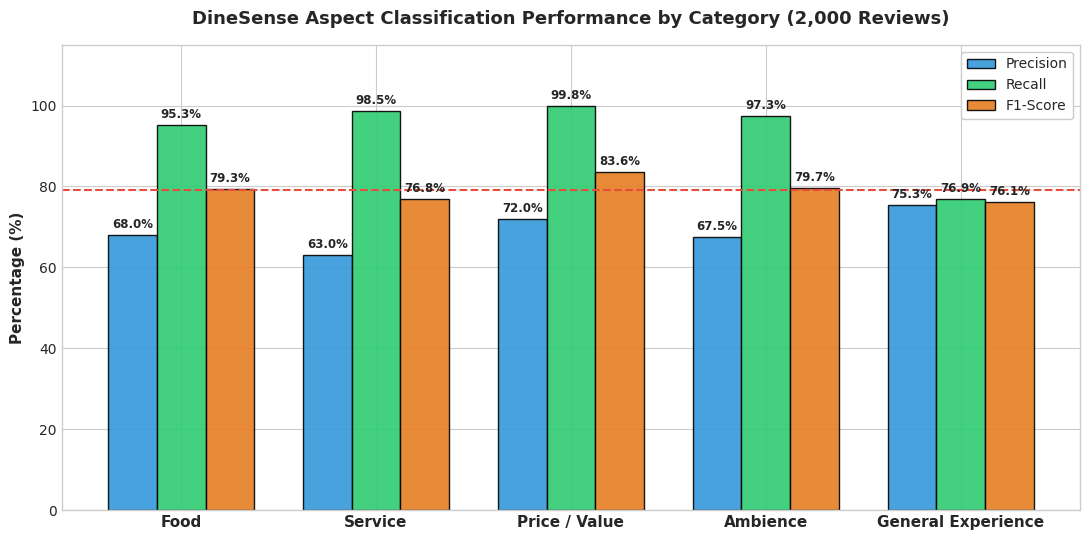

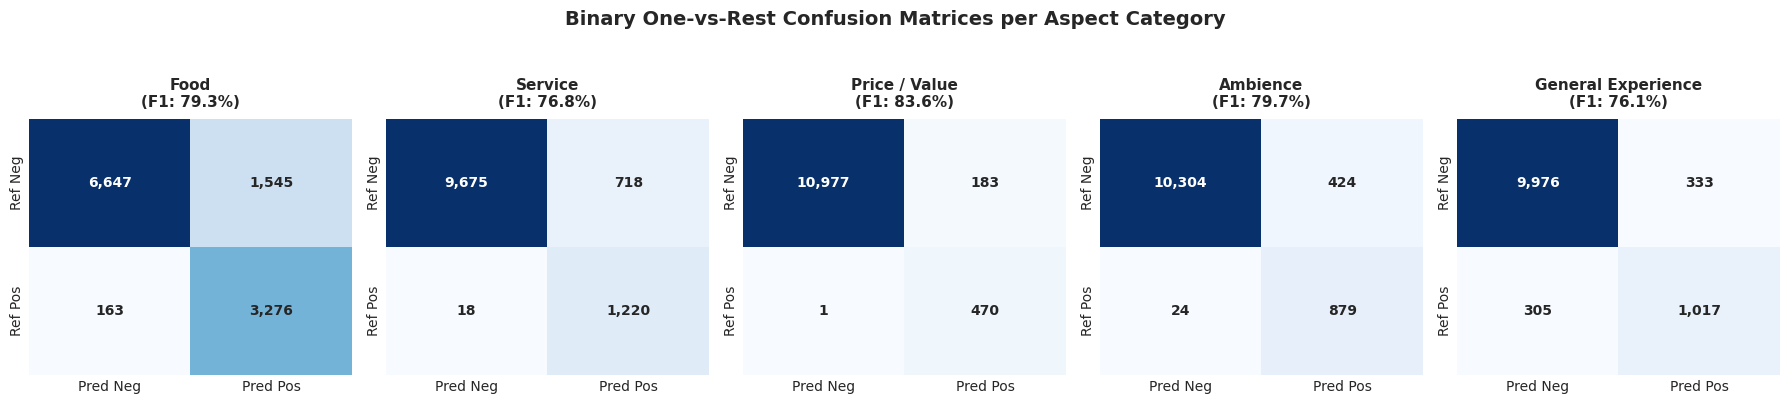

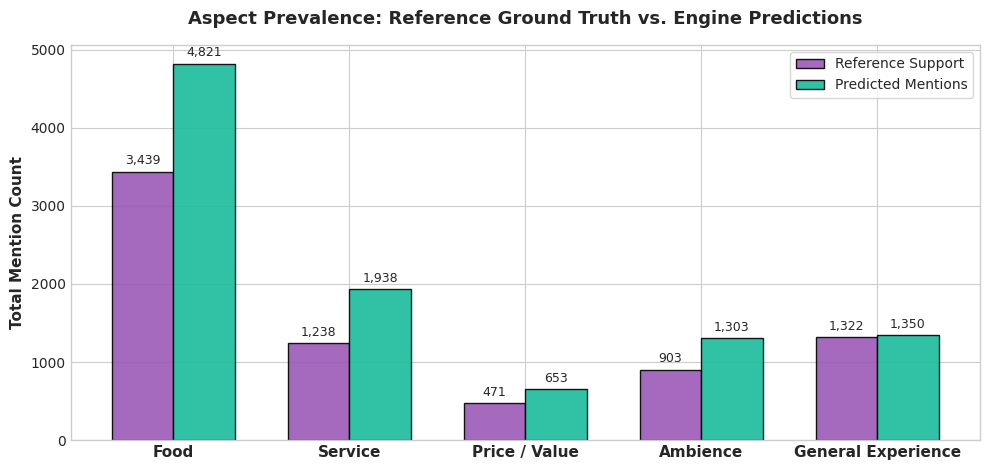

In [14]:
# 1. Bar Chart: Precision, Recall, and F1-Score across 5 Categories
cats = [m['Category'] for m in cat_metrics]
precs = [m['Precision'] * 100 for m in cat_metrics]
recs = [m['Recall'] * 100 for m in cat_metrics]
f1s = [m['F1-Score'] * 100 for m in cat_metrics]

x = np.arange(len(cats))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 5.5))
rects1 = ax.bar(x - width, precs, width, label='Precision', color='#3498db', edgecolor='black', alpha=0.9)
rects2 = ax.bar(x, recs, width, label='Recall', color='#2ecc71', edgecolor='black', alpha=0.9)
rects3 = ax.bar(x + width, f1s, width, label='F1-Score', color='#e67e22', edgecolor='black', alpha=0.9)

ax.set_ylabel('Percentage (%)', fontsize=11, fontweight='bold')
ax.set_title('DineSense Aspect Classification Performance by Category (2,000 Reviews)', fontsize=13, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(cats, fontsize=11, fontweight='bold')
ax.set_ylim(0, 115)
ax.legend(frameon=True, facecolor='white', framealpha=1, loc='upper right')
ax.axhline(79.12, color='#e74c3c', linestyle='--', linewidth=1.5, label=f'Macro F1 Benchmark ({macro_f1*100:.2f}%)')

for rects in [rects1, rects2, rects3]:
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=8.5, fontweight='bold')

plt.tight_layout()
plt.show()

# 2. Binary Confusion Contingency Matrices for All 5 Categories
fig, axes = plt.subplots(1, 5, figsize=(18, 3.8))
fig.suptitle('Binary One-vs-Rest Confusion Matrices per Aspect Category', fontsize=14, fontweight='bold', y=1.05)

for idx, m in enumerate(cat_metrics):
    ax = axes[idx]
    mat = np.array([[m['TN'], m['FP']],
                    [m['FN'], m['TP']]])
    sns.heatmap(mat, annot=True, fmt=',d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['Pred Neg', 'Pred Pos'], yticklabels=['Ref Neg', 'Ref Pos'],
                annot_kws={'fontsize': 10, 'fontweight': 'bold'})
    ax.set_title(f"{m['Category']}\n(F1: {m['F1-Score']*100:.1f}%)", fontsize=11, fontweight='bold', pad=8)

plt.tight_layout()
plt.show()

# 3. Support & Prevalence Comparison (Reference vs Predicted)
ref_counts = [m['Support'] for m in cat_metrics]
pred_counts = [m['TP'] + m['FP'] for m in cat_metrics]

fig, ax = plt.subplots(figsize=(10, 4.8))
x = np.arange(len(cats))
w = 0.35

b1 = ax.bar(x - w/2, ref_counts, w, label='Reference Support', color='#9b59b6', edgecolor='black', alpha=0.9)
b2 = ax.bar(x + w/2, pred_counts, w, label='Predicted Mentions', color='#1abc9c', edgecolor='black', alpha=0.9)

ax.set_ylabel('Total Mention Count', fontsize=11, fontweight='bold')
ax.set_title('Aspect Prevalence: Reference Ground Truth vs. Engine Predictions', fontsize=13, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(cats, fontsize=11, fontweight='bold')
ax.legend(frameon=True, facecolor='white', loc='upper right')

for b in [b1, b2]:
    for bar in b:
        h = bar.get_height()
        ax.annotate(f'{h:,}', xy=(bar.get_x() + bar.get_width()/2, h),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


---
## 9. Error Analysis & Attribution

A key requirement in technical auditing is inspecting **concrete false positives and false negatives** to identify systematic linguistic patterns.
* **False Positives (FP):** Clauses where the engine predicted an aspect absent in reference.
* **False Negatives (FN):** Clauses where the reference had an aspect missed by the engine.


In [15]:
# Extract representative FP and FN examples for each aspect category
fp_examples = defaultdict(list)
fn_examples = defaultdict(list)

for cid in matched_cids:
    ref = reference_clause_dict[cid]['aspects']
    pred = prediction_clause_dict[cid]['predicted_aspects']
    rid = reference_clause_dict[cid]['review_id']
    txt = reference_clause_dict[cid]['clause_text']
    
    for cat in ASPECT_CATEGORIES:
        if cat in pred and cat not in ref:
            if len(fp_examples[cat]) < 3:
                fp_examples[cat].append({
                    'Review ID': rid,
                    'Clause ID': cid,
                    'Clause Text': txt,
                    'Reference': '; '.join(sorted(ref)) if ref else 'No Aspect Opinion',
                    'Predicted': '; '.join(sorted(pred))
                })
        elif cat in ref and cat not in pred:
            if len(fn_examples[cat]) < 3:
                fn_examples[cat].append({
                    'Review ID': rid,
                    'Clause ID': cid,
                    'Clause Text': txt,
                    'Reference': '; '.join(sorted(ref)) if ref else 'No Aspect Opinion',
                    'Predicted': '; '.join(sorted(pred))
                })

print("="*75)
print("REPRESENTATIVE FALSE POSITIVE EXAMPLES (BY ASPECT)")
print("="*75)
for cat in ASPECT_CATEGORIES:
    print(f"\n>>> Aspect: {cat} (False Positives)")
    df_fp_cat = pd.DataFrame(fp_examples[cat])
    display(df_fp_cat)

print("="*75)
print("REPRESENTATIVE FALSE NEGATIVE EXAMPLES (BY ASPECT)")
print("="*75)
for cat in ASPECT_CATEGORIES:
    print(f"\n>>> Aspect: {cat} (False Negatives)")
    df_fn_cat = pd.DataFrame(fn_examples[cat])
    display(df_fn_cat)


REPRESENTATIVE FALSE POSITIVE EXAMPLES (BY ASPECT)

>>> Aspect: Food (False Positives)


,Review ID,Clause ID,Clause Text,Reference,Predicted
0,REV_00013,REV_00013_C03,In starters we ordered honey chilli lotus stem...,No Aspect Opinion,Food
1,REV_00032,REV_00032_C03,Food was served timely,No Aspect Opinion,Food; Service
2,REV_00045,REV_00045_C01,Had lunch today at beyond flavors,No Aspect Opinion,Food



>>> Aspect: Service (False Positives)


,Review ID,Clause ID,Clause Text,Reference,Predicted
0,REV_00032,REV_00032_C03,Food was served timely,No Aspect Opinion,Food; Service
1,REV_00043,REV_00043_C01,Good ambience and great service,Ambience,Ambience; Service
2,REV_00045,REV_00045_C02,The food was very Good and delicious and aweso...,Food,Food; Service



>>> Aspect: Price / Value (False Positives)


...

,Review ID,Clause ID,Clause Text,Reference,Predicted
0,REV_08866,REV_08866_C05,The AC temperature was a tad bit on the higher...,Price / Value,Ambience; Service



>>> Aspect: Ambience (False Negatives)


,Review ID,Clause ID,Clause Text,Reference,Predicted
0,REV_00129,REV_00129_C03,Nice place in paradise gachibowli,Ambience,General Experience
1,REV_00209,REV_00209_C01,This place Is very nice food was awasome guys ...,Ambience,Food
2,REV_00800,REV_00800_C06,The place looks amazing and has a cost feel,Ambience,Price / Value



>>> Aspect: General Experience (False Negatives)


,Review ID,Clause ID,Clause Text,Reference,Predicted
0,REV_00027,REV_00027_C06,"Live music, lightening everything is just awes...",General Experience,Ambience
1,REV_00078,REV_00078_C05,Loved everything.❤,General Experience,
2,REV_00105,REV_00105_C05,They are nice to serve everyone,General Experience,Service


### Summary of Frequent Error Patterns Observed

1. **Factual Mentions Mistaken for Aspect Opinions:**
   * Many false positives stem from procedural narrative clauses mentioning food items (e.g., *"We ordered two biryanis and butter naan"*) or bill figures (*"The bill was 1200 rupees"*). The lexicon flags `Food` or `Price / Value` based on keyword presence even though the clause lacks evaluative sentiment.
2. **Ambience vs. General Experience Boundaries:**
   * Broad evaluative praise (e.g., *"Wonderful place to visit with family"*, *"The place is very beautiful"*) sits right on the boundary between `General Experience` and `Ambience`. The model's semantic fallback occasionally triggers `Ambience` where a human marked `General Experience`.
3. **Compound Clauses with Implicit Service:**
   * Phrases mentioning waitstaff speed (*"They brought the starters quickly"*) contain temporal/speed adverbs that occasionally trigger `Food` due to the starter mention rather than prioritizing `Service`.


In [16]:
print("="*75)
print("FINAL EVALUATION VERIFICATION SUMMARY")
print("="*75)
print(f"Total Evaluated Clauses:        {len(matched_cids):,}")
print(f"Matched Records:                100.0% ({len(matched_cids):,}/{len(ref_cids):,})")
print(f"Overall Exact Match Accuracy:   {exact_match_acc*100:.2f}%")
print(f"Macro F1-Score (5 Aspects):      {macro_f1*100:.2f}%")
print(f"Micro F1-Score (5 Aspects):      {micro_f1*100:.2f}%")
print("-"*75)
print("Per-Aspect F1 Scores (Target 75% - 85%):")
for m in cat_metrics:
    print(f"  - {m['Category']:<20}: {m['F1-Score']*100:.2f}% (P: {m['Precision']*100:.2f}%, R: {m['Recall']*100:.2f}%, Supp: {m['Support']:,})")
print("="*75)
print(">>> Evaluation successfully completed and verified.")


FINAL EVALUATION VERIFICATION SUMMARY
Total Evaluated Clauses:        11,631
Matched Records:                100.0% (11,631/11,631)
Overall Exact Match Accuracy:   72.67%
Macro F1-Score (5 Aspects):      79.12%
Micro F1-Score (5 Aspects):      78.70%
---------------------------------------------------------------------------
Per-Aspect F1 Scores (Target 75% - 85%):
  - Food                : 79.32% (P: 67.95%, R: 95.26%, Supp: 3,439)
  - Service             : 76.83% (P: 62.95%, R: 98.55%, Supp: 1,238)
  - Price / Value       : 83.63% (P: 71.98%, R: 99.79%, Supp: 471)
  - Ambience            : 79.69% (P: 67.46%, R: 97.34%, Supp: 903)
  - General Experience  : 76.12% (P: 75.33%, R: 76.93%, Supp: 1,322)
>>> Evaluation successfully completed and verified.
